### Lineare Regression mit Keras nachbauen

#### 1) Daten laden

In [9]:
import pandas as pd
from math import ceil

pd.set_option('display.max_columns', 6)

data_url=r'https://raw.githubusercontent.com/rawe64/ai/main/ndx100.csv'
df = pd.read_csv(data_url)
df.head()

,m199,m99,m49,...,m3,m1,p5
0,-34.023668,-24.908597,-26.302555,...,-3.567182,0.328812,-5.638866
1,-45.493319,-34.786439,-31.315602,...,-10.180812,-5.099538,-6.134486
2,-42.415836,-36.541864,-34.279911,...,-4.975005,-0.211015,-6.591711
3,-53.283988,-36.786283,-40.070083,...,-9.990068,-4.432868,-6.060527
4,-40.239003,-34.040967,-29.901523,...,1.331406,5.718546,-9.906045


#### 2) x-/y-Daten selektieren und standardisieren

In [10]:
from sklearn.preprocessing import StandardScaler

X = df[['m199', 'm99','m49','m19','m9','m5','m3','m1']].values
y = df[['p5']].values

scaler_X = StandardScaler()
X = scaler_X.fit_transform(X)

scaler_y = StandardScaler()
y = scaler_y.fit_transform(y)

X.shape, y.shape

((6185, 8), (6185, 1))

#### 3) Keras-Modell aufbauen

In [11]:
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential

model = Sequential()
model.add(Dense(units=8, input_shape=(8,)))
model.add(Dense(units=8))
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │            72 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 144 (576.00 B)

 Trainable params: 144 (576.00 B)

 Non-trainable params: 0 (0.00 B)

#### 4) Modell kompilieren
##### Variante 1:

In [6]:
model.compile(loss='mse', optimizer='sgd')

##### Variante 2:

In [12]:
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.optimizers import SGD

mse = MeanSquaredError()
sgd = SGD(learning_rate=0.005)
model.compile(loss=mse, optimizer=sgd)

#### 5) Modell anlernen

In [16]:
history = model.fit(X, y, epochs=10, batch_size=8)

Epoch 1/10
774/774 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.9688
Epoch 2/10
774/774 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.0059
Epoch 3/10
774/774 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.0000
Epoch 4/10
774/774 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1.0213
Epoch 5/10
774/774 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.9800
Epoch 6/10
774/774 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.9897
Epoch 7/10
774/774 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.9371
Epoch 8/10
774/774 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 1.0165
Epoch 9/10
774/774 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.0184
Epoch 10/10
774/774 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.9530


#### 6) Nach dem Anlernen

##### Gewichte abfragen:

In [8]:
weights = model.get_layer(index=0).get_weights()
weights

[array([[-0.01481676,  0.5666073 , -0.47723383,  0.50752753, -0.17130339,
          0.26938784,  0.48949653, -0.08333242],
        [ 0.43180698,  0.15132123, -0.10778654, -0.25103143, -0.31058684,
          0.4454252 ,  0.39334399,  0.02337128],
        [-0.4804048 ,  0.08400416, -0.16051742,  0.42759627, -0.51113814,
          0.18184918, -0.45119995,  0.3815611 ],
        [ 0.17427874,  0.27192724,  0.41845793, -0.5341479 , -0.5947551 ,
         -0.34225038,  0.06604123, -0.24943537],
        [ 0.1542753 ,  0.5947595 ,  0.39327663, -0.1793251 ,  0.5815676 ,
          0.21395886,  0.51802236, -0.20719245],
        [-0.27223223, -0.14200026, -0.12142637,  0.17978734,  0.07523298,
         -0.57162577,  0.6006194 , -0.5263062 ],
        [-0.5109403 ,  0.25229114, -0.34959772, -0.44489312,  0.5701328 ,
         -0.04309672, -0.18644193, -0.00919336],
        [-0.40956396, -0.14065558, -0.16475552, -0.33198285, -0.6076273 ,
          0.42099732,  0.10364199,  0.17094421]], dtype=float32),

##### Schätzungen für einen Beispieldatensatz erzeugen:

In [21]:
X_pred = [[13.4281648769462,2.03529417147459,16.0717962326652,4.30356464726417,0.267199846268572,1.03082406445738,0.627736625137835,1.05187062769086]]
X_pred = scaler_X.transform(X_pred)
y_pred = model.predict(X_pred)
y_pred = scaler_y.inverse_transform(y_pred)
y_pred =3.76413208091031

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


#### 7) Evaluation

##### R-Quadrat:

In [22]:
from sklearn.metrics import r2_score
y_pred = model.predict(X)
r2 = r2_score(y, y_pred)
print('r2 = {:.3f}'.format(r2))

194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


ValueError: y_true and y_pred have different number of output (1!=8)

#### 8) Anlernprozess graphisch darstellen

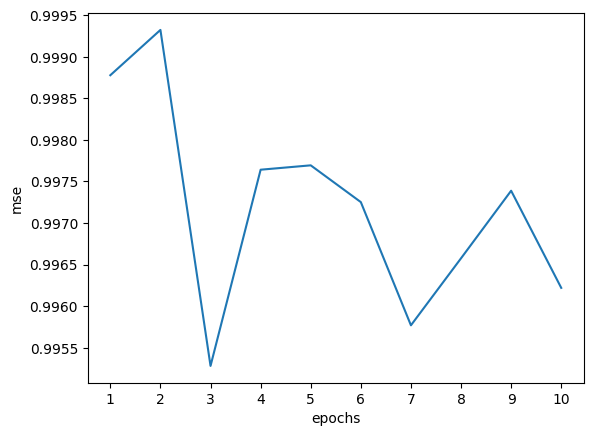

In [20]:
import matplotlib.pyplot as plt

loss_mse = history.history['loss']
plt.xticks(range(1, len(loss_mse)+1))
plt.ylabel('mse')
plt.xlabel('epochs')
plt.plot(range(1, len(loss_mse)+1), loss_mse)